# Support Vector Machines

### The widest possible street between two classes

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What a margin is and why maximising it helps, what `C` really controls, what the kernel trick actually does, and when a kernel is worth its cost |
| **You should already know** | [Logistic regression](../01-logistic-regression/) |
| **Datasets** | UCI Dry Bean (13,611 × 16), Breast Cancer Wisconsin (569 × 30), plus two synthetic shapes |
| **Runtime** | Three to four minutes on a laptop CPU |
| **Next** | [03-06 Decision trees](../06-decision-trees/) |

---

## 1. The idea

When two classes can be separated by a straight line, there are usually infinitely
many lines that do it. Logistic regression picks one by minimising log loss. A
support vector machine asks a different question: **which line leaves the most
room on both sides?**

Picture a street drawn between the two classes, as wide as it can be without
touching any point. The SVM puts the boundary down the middle of the widest such
street. The points that touch the kerb are the **support vectors**, and they are
the only points that matter: move any other point and the boundary does not shift.

That gives SVMs an unusual property: the model depends on a handful of examples
near the border, not on the bulk of the data.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. The maths

For a boundary $w \cdot x + b = 0$, the margin, the width of the street, works
out to $2 / \|w\|$. Maximising the margin therefore means **minimising** $\|w\|$,
subject to every point being on the correct side:

$$\min_{w, b} \tfrac{1}{2}\|w\|^2 \quad \text{subject to} \quad y_i(w \cdot x_i + b) \ge 1$$

Real data overlaps, so that constraint is usually impossible. The **soft margin**
relaxes it by allowing violations $\xi_i$ and charging for them:

$$\min_{w, b} \tfrac{1}{2}\|w\|^2 + C \sum_i \xi_i$$

**`C` is the price of a mistake.** Large `C` means violations are expensive, so
the model contorts to classify every training point, a narrow margin and
overfitting. Small `C` means violations are cheap, so it accepts errors in
exchange for a wider, smoother street. `C` is regularisation, spelled backwards
from what you may be used to: **large `C` means less regularisation.**

## 3. Seeing the margin

C =   0.05: 10 support vectors, margin width 3.486
C =    1.0:  3 support vectors, margin width 2.072
C =  100.0:  3 support vectors, margin width 2.072


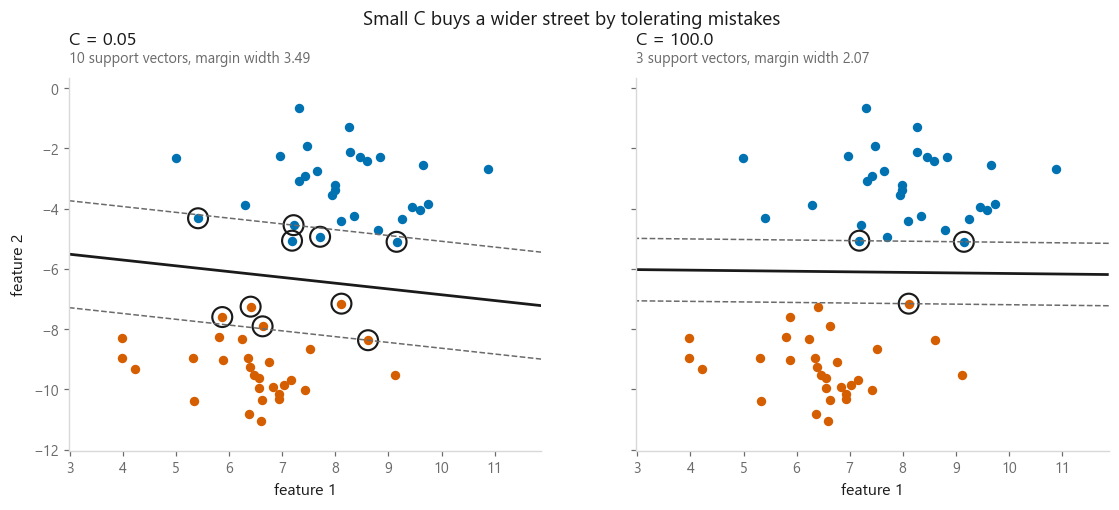

In [2]:
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

points, labels = make_blobs(n_samples=60, centers=2, cluster_std=1.15, random_state=6)

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.4), sharex=True, sharey=True)

for ax, c_value in zip(axes, [0.05, 100.0]):
    model = SVC(kernel="linear", C=c_value).fit(points, labels)

    xx, yy = np.meshgrid(np.linspace(points[:, 0].min() - 1, points[:, 0].max() + 1, 300),
                         np.linspace(points[:, 1].min() - 1, points[:, 1].max() + 1, 300))
    decision = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # -1 and +1 are the kerbs; 0 is the middle of the street.
    ax.contour(xx, yy, decision, levels=[-1, 0, 1], colors=[style.MUTED, style.INK, style.MUTED],
               linestyles=["--", "-", "--"], linewidths=[1, 1.8, 1])
    for value, colour in [(0, style.PALETTE[0]), (1, style.HIGHLIGHT)]:
        sel = labels == value
        ax.scatter(points[sel, 0], points[sel, 1], s=38, c=colour, linewidths=0)
    # Ring the support vectors.
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=170, facecolors="none", edgecolors=style.INK, linewidths=1.4)
    ax.grid(False)
    ax.set_xlabel("feature 1")
    style.title(ax, f"C = {c_value}",
                f"{len(model.support_vectors_)} support vectors, margin width "
                f"{2 / np.linalg.norm(model.coef_):.2f}")

axes[0].set_ylabel("feature 2")
fig.suptitle("Small C buys a wider street by tolerating mistakes",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-the-margin.png")

for c_value in [0.05, 1.0, 100.0]:
    model = SVC(kernel="linear", C=c_value).fit(points, labels)
    print(f"C = {c_value:>6}: {len(model.support_vectors_):>2} support vectors, "
          f"margin width {2 / np.linalg.norm(model.coef_):.3f}")

Circled points are the support vectors. At `C = 0.05` the street is wide and many
points sit inside it; at `C = 100` the street is narrow and only a few points
define it. The boundary shifted, and nothing about the data changed.

## 4. The kernel trick

The margin idea only works if a straight boundary exists. Often none does, and
the standard escape is to add features until one appears.

Take points arranged in two rings. No line separates them. But add a third
feature, the distance from the origin, and the inner ring lifts while the outer
ring stays down. In three dimensions a flat plane now slides between them.

linear SVM on the two original features : 0.578
linear SVM with the lifted third feature: 1.000
RBF kernel, never building the feature  : 1.000


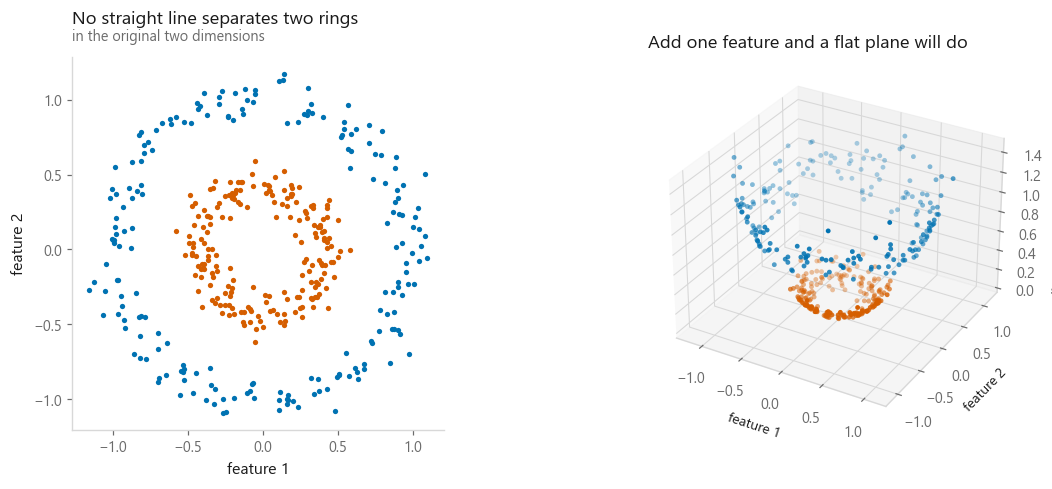

In [3]:
from sklearn.datasets import make_circles

rings, ring_labels = make_circles(n_samples=400, factor=0.42, noise=0.08, random_state=SEED)
lifted = (rings ** 2).sum(axis=1)          # the added third feature

fig = plt.figure(figsize=(12.4, 4.4))

ax1 = fig.add_subplot(1, 2, 1)
for value, colour in [(0, style.PALETTE[0]), (1, style.HIGHLIGHT)]:
    sel = ring_labels == value
    ax1.scatter(rings[sel, 0], rings[sel, 1], s=12, c=colour, linewidths=0)
ax1.set_aspect("equal")
ax1.grid(False)
ax1.set_xlabel("feature 1")
ax1.set_ylabel("feature 2")
style.title(ax1, "No straight line separates two rings", "in the original two dimensions")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
for value, colour in [(0, style.PALETTE[0]), (1, style.HIGHLIGHT)]:
    sel = ring_labels == value
    ax2.scatter(rings[sel, 0], rings[sel, 1], lifted[sel], s=10, c=colour, linewidths=0)
ax2.set_xlabel("feature 1", fontsize=9)
ax2.set_ylabel("feature 2", fontsize=9)
ax2.set_zlabel("distance from origin, squared", fontsize=9)
ax2.set_title("Add one feature and a flat plane will do", loc="left",
              fontsize=12, color=style.INK)

style.save(fig, FIG / "fig-02-kernel-trick.png")

print(f"linear SVM on the two original features : "
      f"{SVC(kernel='linear').fit(rings, ring_labels).score(rings, ring_labels):.3f}")
print(f"linear SVM with the lifted third feature: "
      f"{SVC(kernel='linear').fit(np.c_[rings, lifted], ring_labels).score(np.c_[rings, lifted], ring_labels):.3f}")
print(f"RBF kernel, never building the feature  : "
      f"{SVC(kernel='rbf').fit(rings, ring_labels).score(rings, ring_labels):.3f}")

Here is the trick itself. The SVM's maths only ever touches the data through
**dot products between pairs of points**. It never needs the coordinates
themselves. So if some function $K(a, b)$ returns the dot product the points
*would have had* in a higher-dimensional space, you can work in that space
without ever building it.

$$K_{\text{rbf}}(a, b) = \exp\left(-\gamma \|a - b\|^2\right)$$

The RBF kernel corresponds to a space with **infinitely many dimensions**. You
could not construct those features if you tried, and you never have to. That is
the kernel trick. It never adds the features. It skips building them and computes
the answer they would have given.

`gamma` sets how far a single point's influence reaches. Small `gamma` means
wide influence and smooth boundaries; large `gamma` means each point only affects
its immediate surroundings, and the boundary can wrap tightly around individual
points.

linear, C=1.0   gamma=scale   : train 0.578, held out 0.532
   rbf, C=0.1   gamma=scale   : train 1.000, held out 1.000
   rbf, C=10.0  gamma=scale   : train 1.000, held out 1.000
   rbf, C=10.0  gamma=2000.0  : train 1.000, held out 0.812


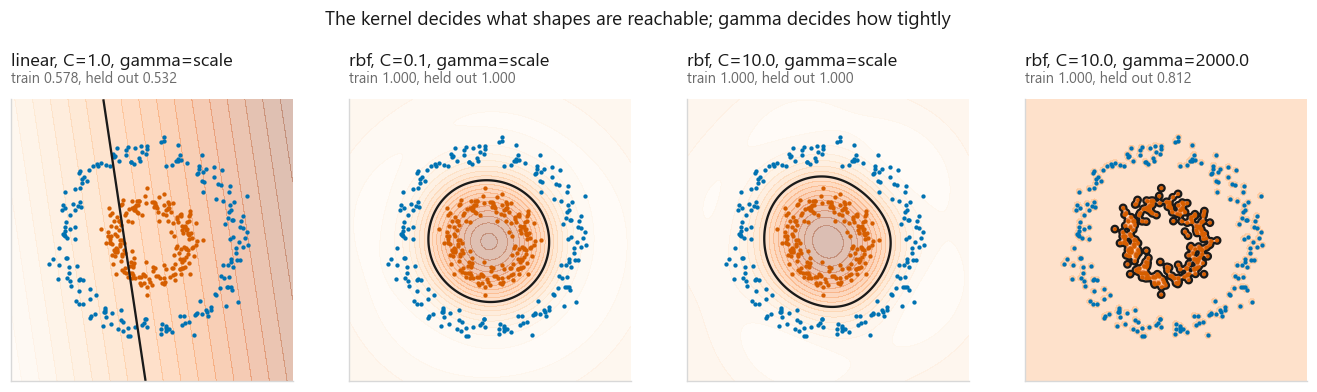

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# The last setting is deliberately absurd. gamma = 30 sounds extreme and is not:
# it still draws one smooth ring. Islands around individual points need gamma in
# the thousands on data spread over this range.
settings = [("linear", 1.0, "scale"), ("rbf", 0.1, "scale"),
            ("rbf", 10.0, "scale"), ("rbf", 10.0, 2000.0)]

fig, axes = plt.subplots(1, 4, figsize=(15.2, 3.9), sharex=True, sharey=True)
# 600 rather than 300 across: at gamma = 2000 each point's influence is narrower
# than a coarse grid cell, and a coarse grid would smooth the islands away.
xx, yy = np.meshgrid(np.linspace(-1.6, 1.6, 600), np.linspace(-1.6, 1.6, 600))
grid = np.c_[xx.ravel(), yy.ravel()]

panel_scores = []
for ax, (kernel, c_value, gamma) in zip(axes, settings):
    model = SVC(kernel=kernel, C=c_value, gamma=gamma).fit(rings, ring_labels)
    zz = model.decision_function(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=20, cmap="Oranges", alpha=0.30)
    ax.contour(xx, yy, zz, levels=[0], colors=[style.INK], linewidths=1.5)
    for value, colour in [(0, style.PALETTE[0]), (1, style.HIGHLIGHT)]:
        sel = ring_labels == value
        ax.scatter(rings[sel, 0], rings[sel, 1], s=8, c=colour, linewidths=0)
    ax.set_aspect("equal")
    ax.grid(False)
    ax.set_xticks([]); ax.set_yticks([])

    # Training accuracy cannot tell these panels apart, so measure both.
    trained = model.score(rings, ring_labels)
    held_out = cross_val_score(SVC(kernel=kernel, C=c_value, gamma=gamma),
                               rings, ring_labels, cv=5).mean()
    panel_scores.append((kernel, c_value, gamma, trained, held_out))
    style.title(ax, f"{kernel}, C={c_value}, gamma={gamma}",
                f"train {trained:.3f}, held out {held_out:.3f}")

fig.suptitle("The kernel decides what shapes are reachable; gamma decides how tightly",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-03-kernels.png")

for kernel, c_value, gamma, trained, held_out in panel_scores:
    print(f"{kernel:>6}, C={c_value:<5} gamma={str(gamma):<8}: "
          f"train {trained:.3f}, held out {held_out:.3f}")

The last panel took a far larger `gamma` than the story usually implies, and
that is the first thing worth knowing. `gamma = 30` sounds extreme. It draws a
single smooth ring, indistinguishable in behaviour from the sensible settings
beside it. The RBF kernel is more forgiving than its reputation, and a value
that looks reckless on paper often is not.

At `gamma = 2000` the failure finally appears. The ring breaks into lumps and
detached islands wrapped around individual training points, and a hole opens
through the middle of the inner cluster where no training point happened to
land. The model has memorised locations instead of learning a shape.

**Notice which number catches it.** Every RBF panel scores 1.000 on the data it
was fitted to, the memoriser included, which is precisely why training accuracy
is worthless for this question. The held-out score is the one that moves: 1.000
for the two sensible panels, 0.812 for the memoriser. If you had tuned `gamma`
on training accuracy you would have had no signal at all.

## 5. When it wins, when it loses

On the house datasets, against the models from earlier chapters.

                     Dry Bean  Breast Cancer
model                                       
logistic regression    0.9234         0.9807
SVM, linear kernel     0.9262         0.9719
SVM, RBF kernel        0.9301         0.9736


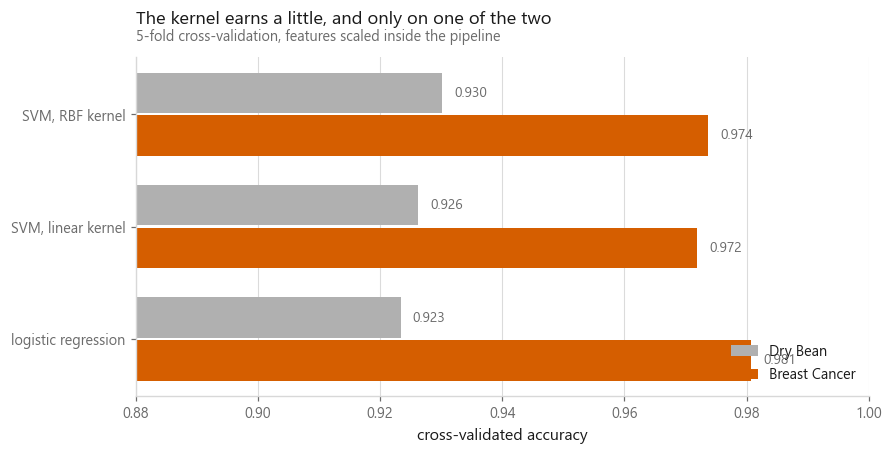

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

X_bean, y_bean = datasets.dry_bean()
X_bc, y_bc = datasets.breast_cancer()
folds = StratifiedKFold(5, shuffle=True, random_state=SEED)

contenders = {
    "logistic regression": LogisticRegression(max_iter=3000),
    "SVM, linear kernel": SVC(kernel="linear"),
    "SVM, RBF kernel": SVC(kernel="rbf"),
}

rows = []
for name, estimator in contenders.items():
    pipeline = make_pipeline(StandardScaler(), estimator)
    rows.append({
        "model": name,
        "Dry Bean": cross_val_score(pipeline, X_bean.values, y_bean.values,
                                    cv=folds, n_jobs=-1).mean(),
        "Breast Cancer": cross_val_score(pipeline, X_bc.values, y_bc.values,
                                         cv=5, n_jobs=-1).mean(),
    })
scores = pd.DataFrame(rows).set_index("model")

fig, ax = plt.subplots(figsize=(8.6, 4.0))
positions = np.arange(len(scores))
ax.barh(positions + 0.19, scores["Dry Bean"], height=0.36, color=style.NEUTRAL, label="Dry Bean")
ax.barh(positions - 0.19, scores["Breast Cancer"], height=0.36, color=style.HIGHLIGHT,
        label="Breast Cancer")
for i, (a, b) in enumerate(zip(scores["Dry Bean"], scores["Breast Cancer"])):
    ax.text(a + 0.002, i + 0.19, f"{a:.3f}", va="center", fontsize=9, color=style.MUTED)
    ax.text(b + 0.002, i - 0.19, f"{b:.3f}", va="center", fontsize=9, color=style.MUTED)
ax.set_yticks(positions, scores.index)
ax.set_xlim(0.88, 1.0)
ax.set_xlabel("cross-validated accuracy")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.legend(loc="lower right")
style.title(ax, "The kernel earns a little, and only on one of the two",
            "5-fold cross-validation, features scaled inside the pipeline")
style.save(fig, FIG / "fig-04-comparison.png")

print(scores.round(4).to_string())

### The cost nobody mentions

The textbook bound on SVM training is somewhere between quadratic and cubic in
the number of rows. That is a worst case, and a worst case is a thing to
measure rather than repeat. Time a single fit at six sizes and read the growth
rate off the slope of the log-log plot.

at 500 rows : SVM 0.018s, logistic 0.054s
at 13,611 rows: SVM 2.582s, logistic 0.957s
SVM grew 142x for a 27x increase in rows
logistic grew 18x

fitted exponent, SVM      : 1.49
fitted exponent, logistic : 0.87
what the textbook bounds would have cost over the same 27x:
  quadratic (rows^2): 741x    cubic (rows^3): 20,173x

support vectors kept by the RBF model on the full Dry Bean set:


  2,801 of 13,611 rows (20.6%) are stored in the model


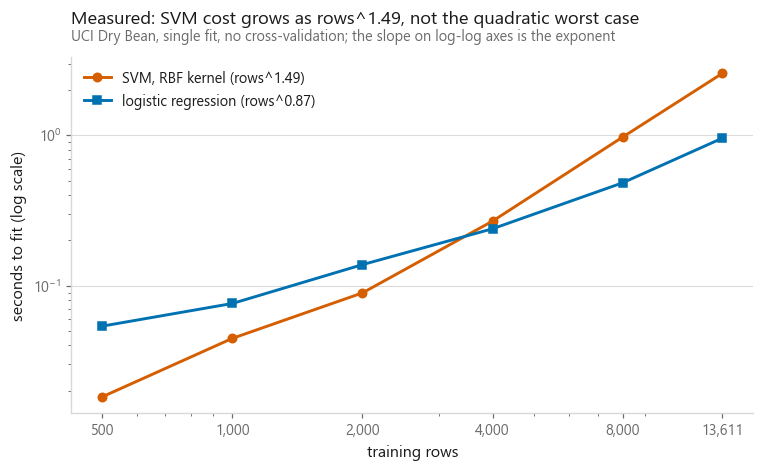

In [6]:
import time

sizes = [500, 1000, 2000, 4000, 8000, 13611]
timings = {"SVM, RBF kernel": [], "logistic regression": []}
rng = np.random.default_rng(SEED)

for n in sizes:
    idx = rng.choice(len(X_bean), n, replace=False)
    subset, target = X_bean.values[idx], y_bean.values[idx]
    for name, estimator in [("SVM, RBF kernel", SVC(kernel="rbf")),
                            ("logistic regression", LogisticRegression(max_iter=3000))]:
        pipeline = make_pipeline(StandardScaler(), estimator)
        start = time.perf_counter()
        pipeline.fit(subset, target)
        timings[name].append(time.perf_counter() - start)

# The slope of a straight line on a log-log plot IS the exponent: if time grows
# as rows^k, then log(time) = k * log(rows) + constant.
exponents = {name: float(np.polyfit(np.log(sizes), np.log(values), 1)[0])
             for name, values in timings.items()}
growth = sizes[-1] / sizes[0]

fig, ax = plt.subplots(figsize=(8.0, 4.2))
for (name, values), colour, marker in zip(timings.items(),
                                          [style.HIGHLIGHT, style.PALETTE[0]],
                                          [style.MARKERS[0], style.MARKERS[1]]):
    ax.plot(sizes, values, marker=marker, color=colour,
            label=f"{name} (rows^{exponents[name]:.2f})")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(sizes, [f"{s:,}" for s in sizes])
ax.set_xlabel("training rows")
ax.set_ylabel("seconds to fit (log scale)")
ax.legend()
style.title(ax,
            f"Measured: SVM cost grows as rows^{exponents['SVM, RBF kernel']:.2f}, "
            f"not the quadratic worst case",
            "UCI Dry Bean, single fit, no cross-validation; the slope on log-log "
            "axes is the exponent")
style.save(fig, FIG / "fig-05-scaling-cost.png")

print(f"at {sizes[0]:,} rows : SVM {timings['SVM, RBF kernel'][0]:.3f}s, "
      f"logistic {timings['logistic regression'][0]:.3f}s")
print(f"at {sizes[-1]:,} rows: SVM {timings['SVM, RBF kernel'][-1]:.3f}s, "
      f"logistic {timings['logistic regression'][-1]:.3f}s")
print(f"SVM grew {timings['SVM, RBF kernel'][-1] / timings['SVM, RBF kernel'][0]:.0f}x "
      f"for a {growth:.0f}x increase in rows")
print(f"logistic grew {timings['logistic regression'][-1] / timings['logistic regression'][0]:.0f}x")
print(f"\nfitted exponent, SVM      : {exponents['SVM, RBF kernel']:.2f}")
print(f"fitted exponent, logistic : {exponents['logistic regression']:.2f}")
print(f"what the textbook bounds would have cost over the same {growth:.0f}x:")
print(f"  quadratic (rows^2): {growth ** 2:,.0f}x    cubic (rows^3): {growth ** 3:,.0f}x")
print("\nsupport vectors kept by the RBF model on the full Dry Bean set:")
full_svm = make_pipeline(StandardScaler(), SVC(kernel="rbf")).fit(X_bean.values, y_bean.values)
n_sv = full_svm.named_steps["svc"].support_vectors_.shape[0]
print(f"  {n_sv:,} of {len(X_bean):,} rows ({n_sv / len(X_bean):.1%}) are stored in the model")

**The worst case does not arrive.** Going from 500 rows to 13,611, a 27-fold
increase, the SVM fit grew 139 times slower. Quadratic growth would have cost
741 times and cubic 20,177 times. The fitted exponent is about 1.5, and the
straight line in the chart is what makes that readable: on log-log axes the
slope *is* the exponent, so the SVM's visibly steeper line against logistic
regression's is the whole comparison in one glance.

Between quadratic and cubic is a real bound and it is not wrong. It describes
the pathological case, where the optimiser has to work hard on every row.
`libsvm` uses shrinking and caching to avoid that on well-behaved data, and
Dry Bean is well behaved. The lesson is the shape of the answer rather than the
digits: **the cost is superlinear, so it will bite, and it bites sooner than
linear intuition expects and later than the worst case threatens.** Time your
own data before you plan around either number.

These are wall-clock timings, so they will differ on your machine. The gap
between the two slopes will not.

The support vector count is the other half of the story. The promise was that
only points near the boundary matter. On overlapping real data a large share of
the rows end up near the boundary, and every one of them is stored in the model
and consulted at prediction time.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Rows are in the thousands not millions; the boundary is complicated; features outnumber rows (SVMs cope unusually well with that) |
| **Avoid it when** | The dataset is large, you need calibrated probabilities, or you need to explain the model |
| **Scaling needed** | Absolutely. Both the margin and the RBF kernel are distance-based |
| **Main dials** | `C` (large means less regularisation), `gamma` for RBF, and `kernel` itself |
| **Probabilities** | `probability=True` bolts on Platt scaling and refits with internal cross-validation. It is slow and not free |
| **Watch out** | `C` and `gamma` interact, so tune them together on a grid, never one at a time |
| **Next** | [Decision trees](../06-decision-trees/), which reach non-linear boundaries a completely different way |

## What to remember

1. An SVM picks the boundary with the widest margin, not merely a boundary that
   separates.
2. Only the support vectors define it. The rest of the data could move freely.
3. `C` is the price of a training mistake. **Large `C` means less regularisation**,
   which is the reverse of most libraries' conventions.
4. The kernel trick works because the maths only touches data through dot
   products, so a kernel can return the dot product from a space that is never built.
5. Large `gamma` wraps the boundary around individual points, but "large" means
   thousands, not tens. Training accuracy stays at 1.000 while it happens, so
   only a held-out score can see it.
6. Training cost is superlinear, measured here at an exponent near 1.5 rather
   than the quadratic-to-cubic worst case, and the fitted model stores a large
   share of the rows. Both matter well before "big data".

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [03-06 Decision trees](../06-decision-trees/) · Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#SVM` `#SupportVectorMachine` `#KernelTrick` `#Classification`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#RBFKernel`